In [ ]:
#Лабораторная работа №3 Горьков Антон 5130901/30201
# Глава 3. Апериодические сигналы

In [ ]:
# Упражнение 3.1
# Запустите и прослушайте примеры из блокнота chap03.ipynb.
# В примере с утечкой замените окно Хэмминга одним из окон,
# предоставляемых NumPy, и посмотрите, как они влияют на утечку.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import SinSignal, decorate

In [50]:
pip install librosa

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.2 MB/s eta 0:00:00 MB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 1.3 MB/s eta 0:00:00m eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 1.5 MB/s eta 0:00:001.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 1.6 MB/s eta 0:00:001.7 MB/s eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [librosa]━ 14/15 [librosa]cikit-learn]
Note: you may need to restart the kernel to use updated packages.


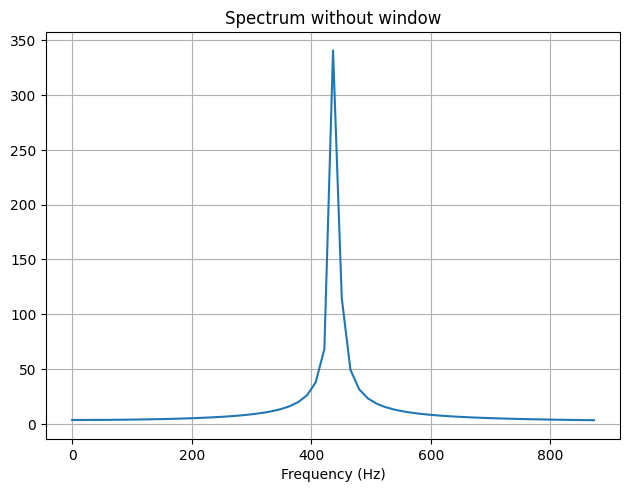

In [3]:
# Повторяем пример с утечкой из chap03:
# берём синус 440 Гц и длину сигнала, которая не содержит целое число периодов.
# Именно из-за этого возникает spectral leakage.

signal = SinSignal(freq=440)
duration = signal.period * 30.25

wave = signal.make_wave(duration)
spectrum = wave.make_spectrum()

spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')
plt.title('Spectrum without window')
plt.grid()
plt.show()

wave.make_audio()

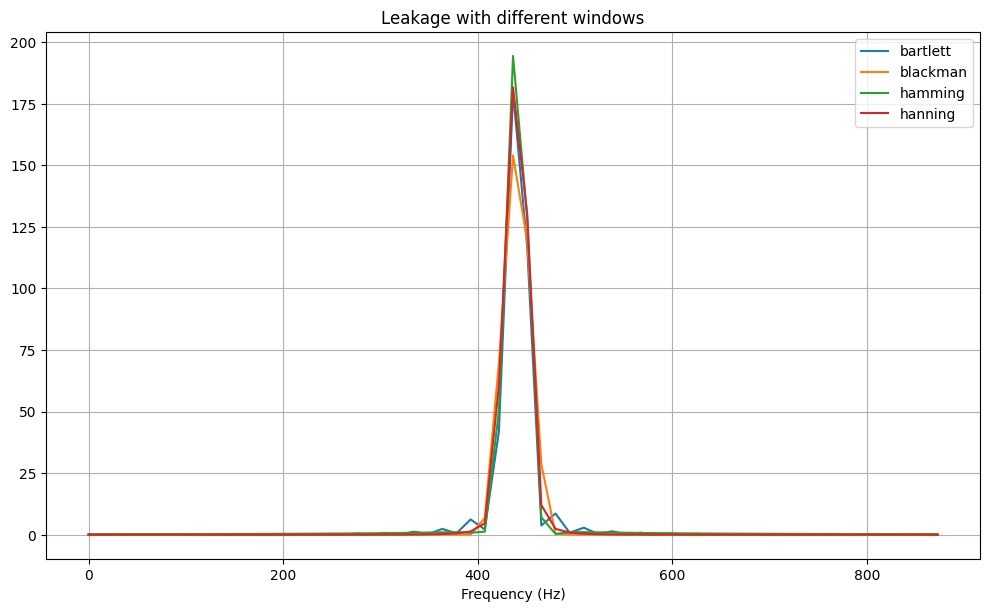

In [4]:
# Сравниваем несколько окон NumPy.
# Все окна применяются к одному и тому же сигналу перед вычислением спектра.

window_funcs = [
    np.bartlett,
    np.blackman,
    np.hamming,
    np.hanning,
]

plt.figure(figsize=(10, 6))

for window_func in window_funcs:
    wave = signal.make_wave(duration)
    wave.ys *= window_func(len(wave.ys))
    
    spectrum = wave.make_spectrum()
    spectrum.plot(high=880, label=window_func.__name__)

decorate(xlabel='Frequency (Hz)')
plt.title('Leakage with different windows')
plt.grid()
plt.legend()
plt.show()

In [6]:
# Упражнение 3.2
# Напишите класс, называемый SawtoothChirp, расширяющий Chirp
# и переопределяющий evaluate для генерации пилообразного сигнала
# с линейно увеличивающейся (или уменьшающейся) частотой.
#
# Подсказка: надо совместить функции evaluate из Chirp и SawtoothSignal.
#
# Нарисуйте эскиз спектрограммы этого сигнала, а затем распечатайте ее.
# Эффект биений должен быть очевиден, а если сигнал внимательно
# прослушать, то биения можно и услышать.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import Chirp, decorate, normalize, unbias

In [26]:
# Класс пилообразного чирпа.
# 1. Берём из Chirp линейно меняющуюся частоту во времени.
# 2. Вместо синусоиды строим пилообразную волну по фазе (числу циклов).


class SawtoothChirp(Chirp):

    def evaluate(self, ts):
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = (2 * np.pi) * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / (2 * np.pi)
        frac, _ = np.modf(cycles)
        ys =  normalize(unbias(frac), self.amp)
        return ys

In [27]:
signal = SawtoothChirp(start=220, end=880)
wave = signal.make_wave(duration=1, framerate=4000)
wave.apodize()
wave.make_audio()

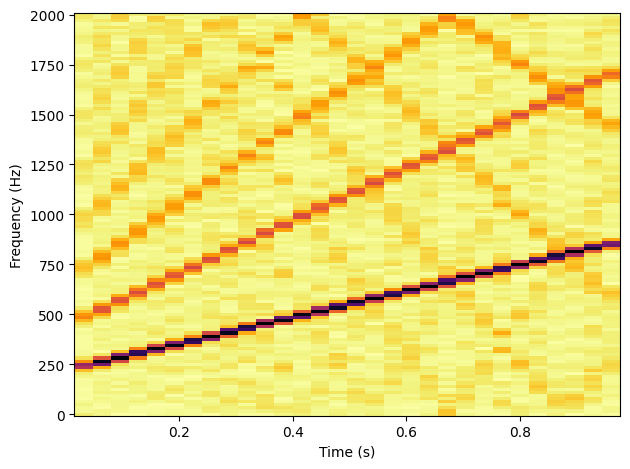

In [28]:
sp = wave.make_spectrogram(256)
sp.plot()
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

In [29]:
# Упражнение 3.3
# Создайте пилообразный чирп, меняющийся от 2500 до 3000 Гц,
# и на его основе сгенерируйте сигнал длительностью 1 с и частотой
# кадров 20 кГц.
#
# Нарисуйте, каким примерно будет Spectrum.
# Затем распечатайте Spectrum и посмотрите, правы ли вы.

In [30]:
signal = SawtoothChirp(start=2500, end=3000)
wave = signal.make_wave(duration=1, framerate=20000)
wave.make_audio()

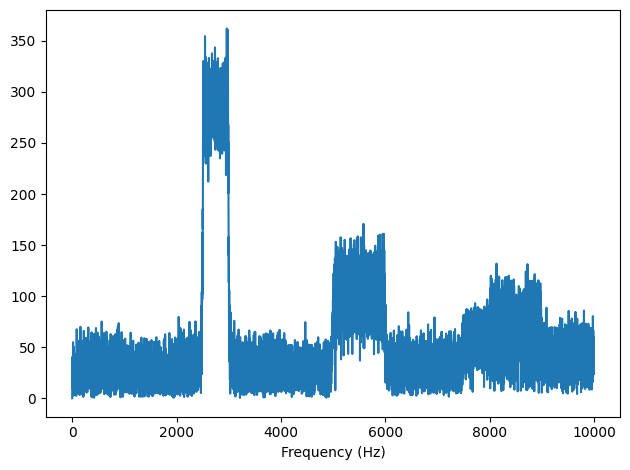

In [31]:
wave.make_spectrum().plot()
decorate(xlabel='Frequency (Hz)')

In [32]:
# Упражнение 3.4
# В музыкальной терминологии глиссандо — это нота, меняющаяся от одной высоты до другой,
# то есть своеобразный чирп.
#
# Найдите или запишите звук глиссандо и распечатайте спектрограмму первых нескольких секунд.
# Для справки: «Rhapsody in Blue» Джорджа Гершвина начинается с известного глиссандо
# на кларнете.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from thinkdsp import Wave, decorate

In [53]:
# Укажи путь к mp3-файлу
filename = 'rhapblue11924.mp3'

ys, framerate = librosa.load(filename, sr=None, mono=True)

wave = Wave(ys, framerate=framerate)

print('framerate =', framerate)
print('duration =', wave.duration)
print('number of samples =', len(wave.ys))

framerate = 11025
duration = 275.8530612244898
number of samples = 3041280


[src/libmpg123/id3.c:INT123_id3_to_utf8():394] warning: Weird tag size 171 for encoding 1 - I will probably trim too early or something but I think the MP3 is broken.


In [60]:
# Берём первые несколько секунд записи
segment_duration = 5.0
segment = wave.segment(start=0, duration=min(segment_duration, wave.duration))

print('Длительность анализируемого фрагмента =', segment.duration)

Длительность анализируемого фрагмента = 5.0


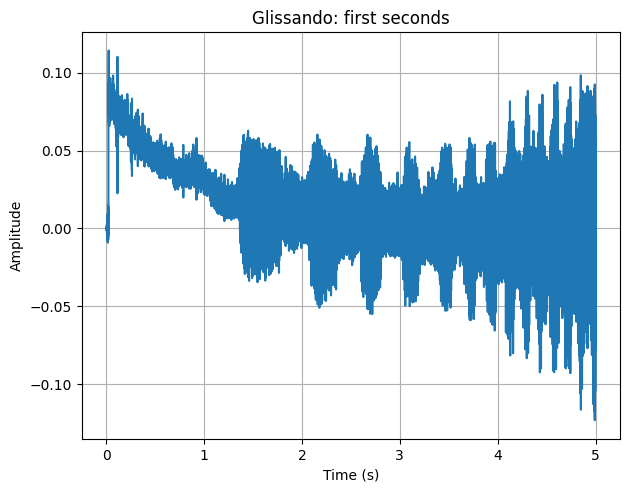

In [61]:
# Смотрим сигнал во временной области
segment.plot()
decorate(xlabel='Time (s)', ylabel='Amplitude')
plt.title('Glissando: first seconds')
plt.grid()
plt.show()

In [62]:
# Слушаем первые несколько секунд
segment.make_audio()

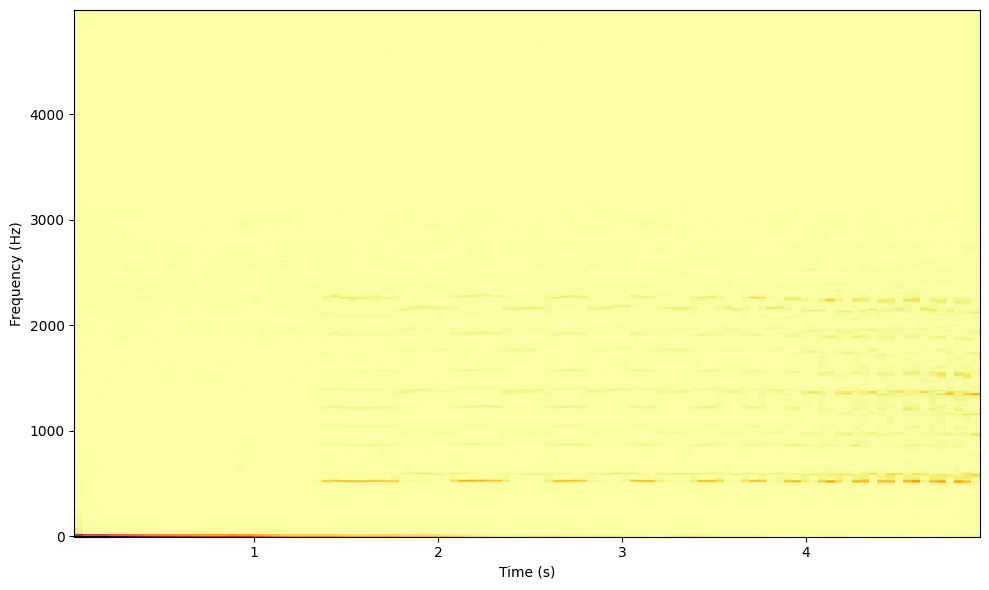

In [66]:
# Строим спектрограмму
spectrogram = segment.make_spectrogram(seg_length=1024)

plt.figure(figsize=(10, 6))
spectrogram.plot(high=5000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')
plt.show()

In [67]:
# Упражнение 3.5
# Тромбонист играет глиссандо, непрерывно дуя в мундштук и двигая кулису тромбона.
# При этом общая длина трубы меняется, а играемая нота обратно пропорциональна этой длине.
#
# Если предположить, что музыкант двигает кулису с постоянной скоростью,
# как будет меняться во времени частота?
#
# Напишите класс, называемый TromboneGliss, расширяющий Chirp и предоставляющий evaluate.
# Создайте сигнал, имитирующий глиссандо на тромбоне от C3 до F3, и обратно до C3.
# C3 = 262 Гц; F3 = 349 Гц.
#
# Напечатайте спектрограмму полученного сигнала.
# На что похоже глиссандо на тромбоне — на линейный или экспоненциальный чирп?

In [68]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import Chirp, decorate

In [69]:
# Если длина трубы меняется линейно со временем:
#     L(t) = L0 + a * t
# а частота обратно пропорциональна длине:
#     f(t) ~ 1 / L(t)
# то частота меняется не линейно, а по закону вида:
#     f(t) = 1 / (b + c * t)
#
# Ниже реализуем такой сигнал.
# Формула подобрана так, чтобы:
#     f(0) = start
#     f(T) = end
#
# Тогда:
#     f(t) = 1 / (1/start + k*t),
# где k выбирается из условия f(T)=end.

class TromboneGliss(Chirp):
    def evaluate(self, ts):
        if len(ts) < 2:
            return np.zeros(len(ts))
        
        T = ts[-1] - ts[0]
        dt = ts[1] - ts[0]
        
        if T == 0:
            freqs = np.full(len(ts), self.start)
        else:
            k = (1 / self.end - 1 / self.start) / T
            t_rel = ts - ts[0]
            freqs = 1 / (1 / self.start + k * t_rel)
        
        # Интегрируем частоту по времени, чтобы получить число циклов
        cycles = np.cumsum(freqs) * dt
        
        # Обычный синусоидальный сигнал
        ys = np.cos(2 * np.pi * cycles)
        return ys

In [70]:
# Создаём глиссандо:
# 1 секунда от C3 до F3
# 1 секунда обратно от F3 до C3

up = TromboneGliss(start=262, end=349).make_wave(duration=1.0, framerate=20000)
down = TromboneGliss(start=349, end=262).make_wave(duration=1.0, framerate=20000)

# Объединяем два фрагмента в один сигнал
wave = up | down

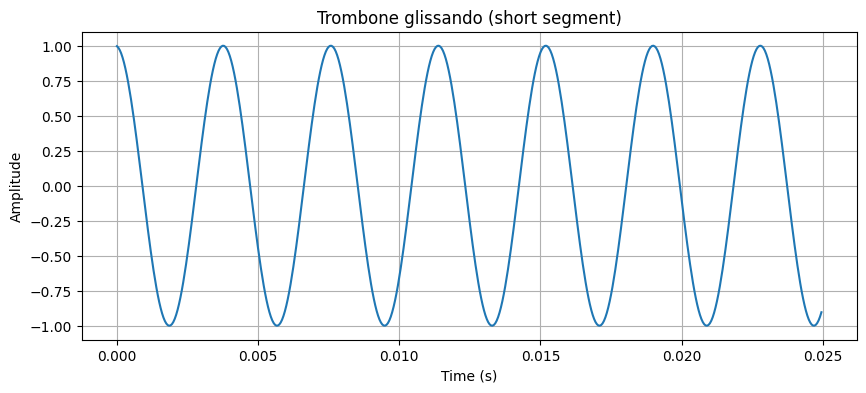

In [71]:
# Смотрим короткий участок сигнала
segment = slice(0, 500)

plt.figure(figsize=(10, 4))
plt.plot(wave.ts[segment], wave.ys[segment])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Trombone glissando (short segment)")
plt.grid()
plt.show()

In [72]:
# Прослушиваем сигнал
wave.make_audio()

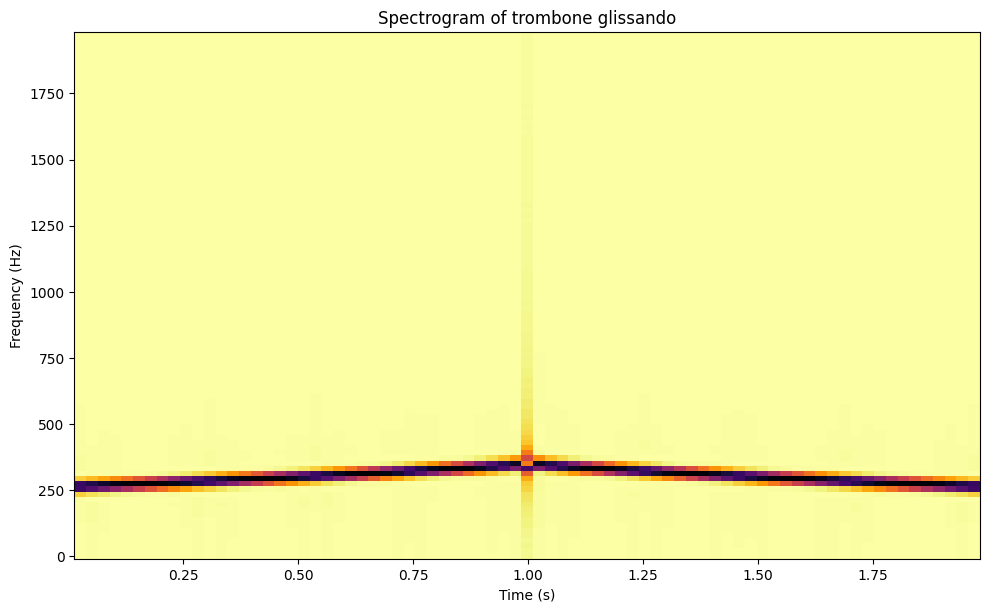

In [73]:
# Строим спектрограмму
spectrogram = wave.make_spectrogram(seg_length=1024)

plt.figure(figsize=(10, 6))
spectrogram.plot(high=2000)
decorate(xlabel="Time (s)", ylabel="Frequency (Hz)")
plt.title("Spectrogram of trombone glissando")
plt.show()

In [ ]:
# Выводы:
# 1. Если длина трубы меняется линейно со временем, а частота обратно пропорциональна длине,
#    то частота меняется не линейно, а как 1 / (a + b*t).
# 2. Значит, тромбонное глиссандо не является линейным chirp.
# 3. Оно и не совсем экспоненциальное: у экспоненциального chirp частота меняется как exp(k*t),
#    а здесь зависимость гиперболическая.
# 4. По форме спектрограммы такое глиссандо обычно ближе к экспоненциальному chirp,
#    чем к линейному, потому что наклон траектории частоты меняется со временем.

In [ ]:
# Упражнение 3.6
# Сделайте или найдите запись серии гласных звуков и посмотрите на спектрограмму.
# Сможете ли вы различить разные гласные?

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

from thinkdsp import Wave, decorate

In [76]:
# Читаем mp3-файл с записью гласных
filename = 'hangyl--prostye-glasnye.mp3'

# sr=None -> оставить исходную частоту дискретизации
# mono=True -> сразу перевести в моно
ys, framerate = librosa.load(filename, sr=None, mono=True)

wave = Wave(ys, framerate=framerate)

print('framerate =', framerate)
print('duration =', wave.duration)
print('number of samples =', len(wave.ys))

framerate = 44100
duration = 27.820408163265306
number of samples = 1226880


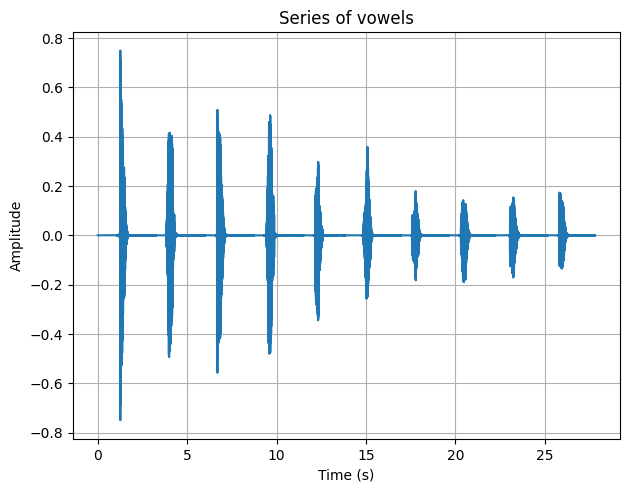

In [77]:
# Смотрим весь сигнал во временной области
wave.plot()
decorate(xlabel='Time (s)', ylabel='Amplitude')
plt.title('Series of vowels')
plt.grid()
plt.show()

In [78]:
# Слушаем запись
wave.make_audio()

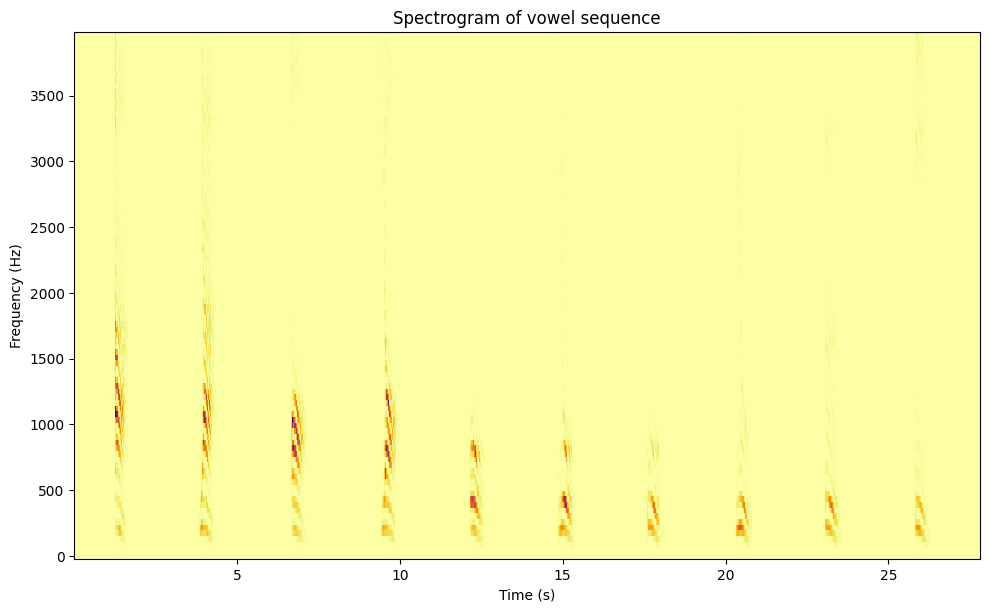

In [82]:
# Строим спектрограмму
# seg_length=1024 даёт достаточно хорошее разрешение по частоте
spectrogram = wave.make_spectrogram(seg_length=1024)

plt.figure(figsize=(10, 6))
spectrogram.plot(high=4000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')
plt.title('Spectrogram of vowel sequence')
plt.show()

In [ ]:
# Выводы:
# 1. Да, разные гласные обычно можно различить по спектрограмме.
# 2. Основное различие связано не с фундаментальной частотой, а с формантами —
#    областями усиленной энергии на определённых частотах.
# 3. У разных гласных форманты расположены по-разному, поэтому на спектрограмме
#    видны разные характерные полосы.
# 4. Если запись достаточно чистая, переходы между гласными заметны визуально.
# 5. Значит, спектрограмма позволяет различать гласные по их спектральной структуре.